In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_excel("Election_Data.xlsx")

In [3]:
df.head()

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,1,Labour,43,3,3,4,1,2,2,female
1,2,Labour,36,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,2,male
3,4,Labour,24,4,2,2,1,4,0,female
4,5,Labour,41,2,2,1,1,6,2,male


In [4]:
df.shape

(1525, 10)

In [5]:
df=df.drop("Unnamed: 0",axis=1)

In [6]:
df.head()

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,Labour,43,3,3,4,1,2,2,female
1,Labour,36,4,4,4,4,5,2,male
2,Labour,35,4,4,5,2,3,2,male
3,Labour,24,4,2,2,1,4,0,female
4,Labour,41,2,2,1,1,6,2,male


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   vote                     1525 non-null   object
 1   age                      1525 non-null   int64 
 2   economic.cond.national   1525 non-null   int64 
 3   economic.cond.household  1525 non-null   int64 
 4   Blair                    1525 non-null   int64 
 5   Hague                    1525 non-null   int64 
 6   Europe                   1525 non-null   int64 
 7   political.knowledge      1525 non-null   int64 
 8   gender                   1525 non-null   object
dtypes: int64(7), object(2)
memory usage: 107.4+ KB


In [7]:
df.dtypes

vote                       object
age                         int64
economic.cond.national      int64
economic.cond.household     int64
Blair                       int64
Hague                       int64
Europe                      int64
political.knowledge         int64
gender                     object
dtype: object

In [8]:
df.isnull().sum()

vote                       0
age                        0
economic.cond.national     0
economic.cond.household    0
Blair                      0
Hague                      0
Europe                     0
political.knowledge        0
gender                     0
dtype: int64

In [9]:
dups=df.duplicated()
df[dups]

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
67,Labour,35,4,4,5,2,3,2,male
626,Labour,39,3,4,4,2,5,2,male
870,Labour,38,2,4,2,2,4,3,male
983,Conservative,74,4,3,2,4,8,2,female
1154,Conservative,53,3,4,2,2,6,0,female
1236,Labour,36,3,3,2,2,6,2,female
1244,Labour,29,4,4,4,2,2,2,female
1438,Labour,40,4,3,4,2,2,2,male


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(1517, 9)

In [12]:
df.describe().T
#almost all are normally distributed as mean and median align in most of the cases

,count,mean,std,min,25%,50%,75%,max
age,1517.0,54.241266,15.701741,24.0,41.0,53.0,67.0,93.0
economic.cond.national,1517.0,3.245221,0.881792,1.0,3.0,3.0,4.0,5.0
economic.cond.household,1517.0,3.137772,0.931069,1.0,3.0,3.0,4.0,5.0
Blair,1517.0,3.335531,1.174772,1.0,2.0,4.0,4.0,5.0
Hague,1517.0,2.749506,1.232479,1.0,2.0,2.0,4.0,5.0
Europe,1517.0,6.740277,3.299043,1.0,4.0,6.0,10.0,11.0
political.knowledge,1517.0,1.540541,1.084417,0.0,0.0,2.0,2.0,3.0


In [13]:
#unique value for categorical variables
for column in df.columns:
    if df[column].dtype=="object":
        print(column.upper(),':',df[column].nunique())
        print(df[column].value_counts().sort_values())
        print('\n')

VOTE : 2
Conservative     460
Labour          1057
Name: vote, dtype: int64


GENDER : 2
male      709
female    808
Name: gender, dtype: int64




C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-

Text(0.5, 1.0, 'Political.knowledge distribution')

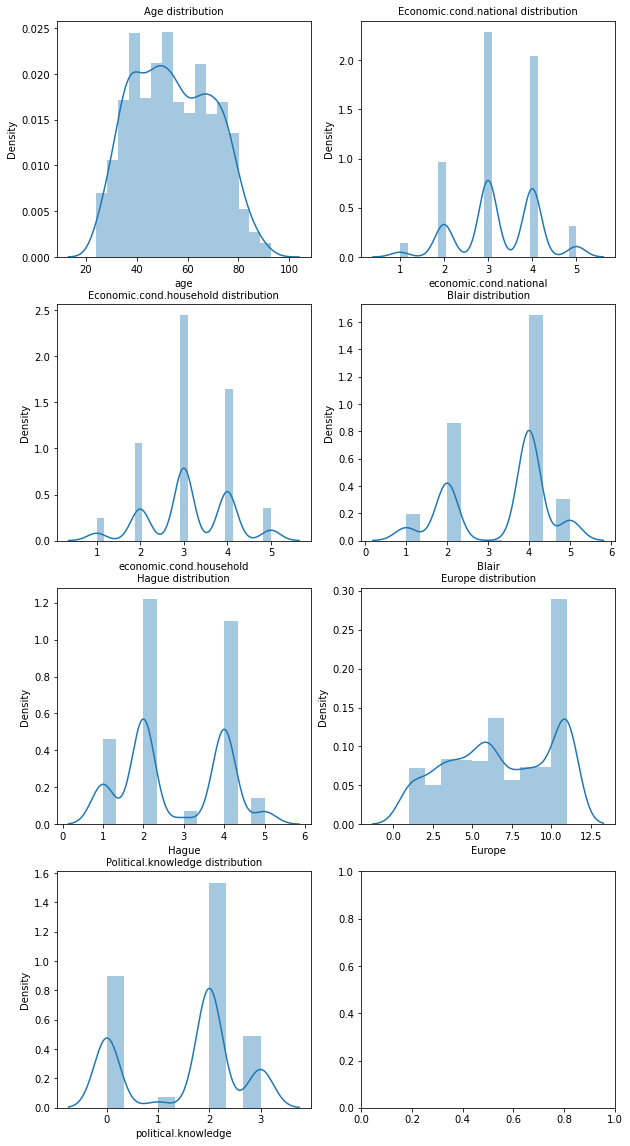

In [14]:
#univariate analysis for numerical column
fig, axes = plt.subplots(nrows=4,ncols=2)
fig.set_size_inches(10,20)
a=sns.distplot(df["age"],ax=axes[0][0])
a.set_title("Age distribution",fontsize=10)

a=sns.distplot(df["economic.cond.national"],ax=axes[0][1])
a.set_title("Economic.cond.national distribution",fontsize=10)

a=sns.distplot(df["economic.cond.household"],ax=axes[1][0])
a.set_title("Economic.cond.household distribution",fontsize=10)

a=sns.distplot(df["Blair"],ax=axes[1][1])
a.set_title("Blair distribution",fontsize=10)

a=sns.distplot(df["Hague"],ax=axes[2][0])
a.set_title("Hague distribution",fontsize=10)

a=sns.distplot(df["Europe"],ax=axes[2][1])
a.set_title("Europe distribution",fontsize=10)

a=sns.distplot(df["political.knowledge"],ax=axes[3][0])
a.set_title("Political.knowledge distribution",fontsize=10)

C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='vote', ylabel='count'>

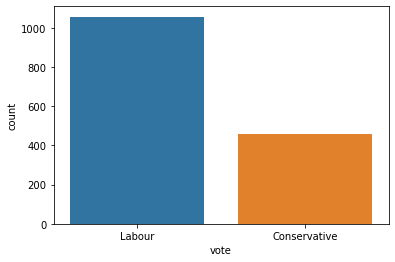

In [15]:
#univariate for categorical variables
sns.countplot(df["vote"])

C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='gender', ylabel='count'>

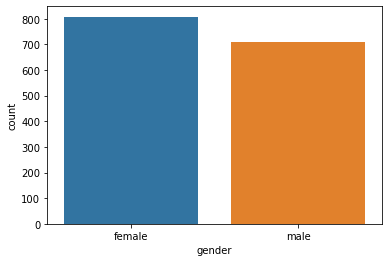

In [16]:
sns.countplot(df["gender"])

C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


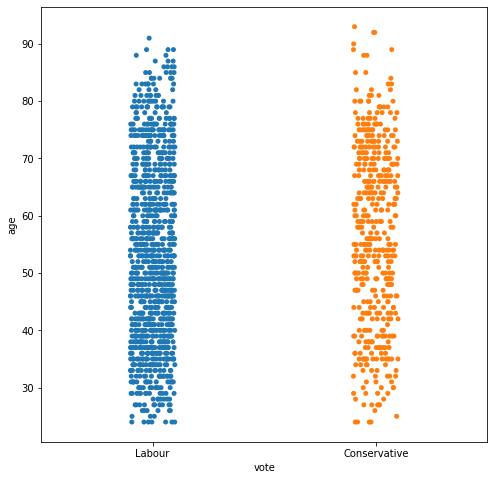

In [9]:
#bivariate analysis
plt.figure(figsize=(8,8))
sns.stripplot(df["vote"],df["age"],jitter=True);
plt.show()

C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


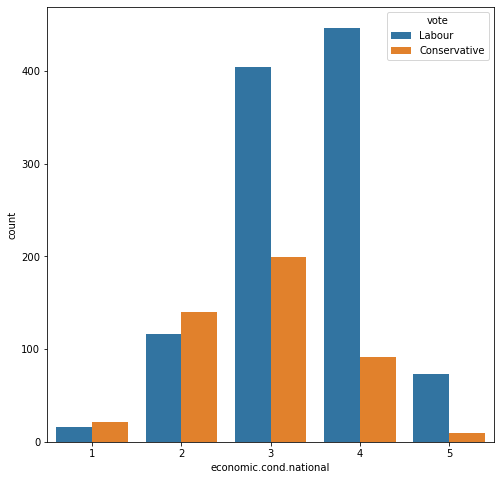

In [18]:
plt.figure(figsize=(8,8))
sns.countplot(df["economic.cond.national"],hue=df["vote"]);
plt.show()

C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


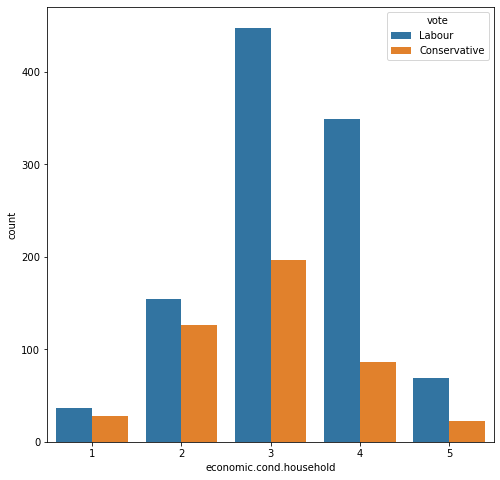

In [19]:
plt.figure(figsize=(8,8))
sns.countplot(df["economic.cond.household"],hue=df["vote"]);
plt.show()

C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


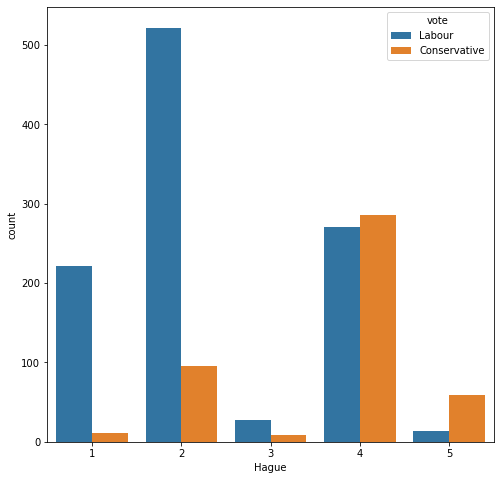

In [20]:
plt.figure(figsize=(8,8))
sns.countplot(df["Hague"],hue=df["vote"]);
plt.show()

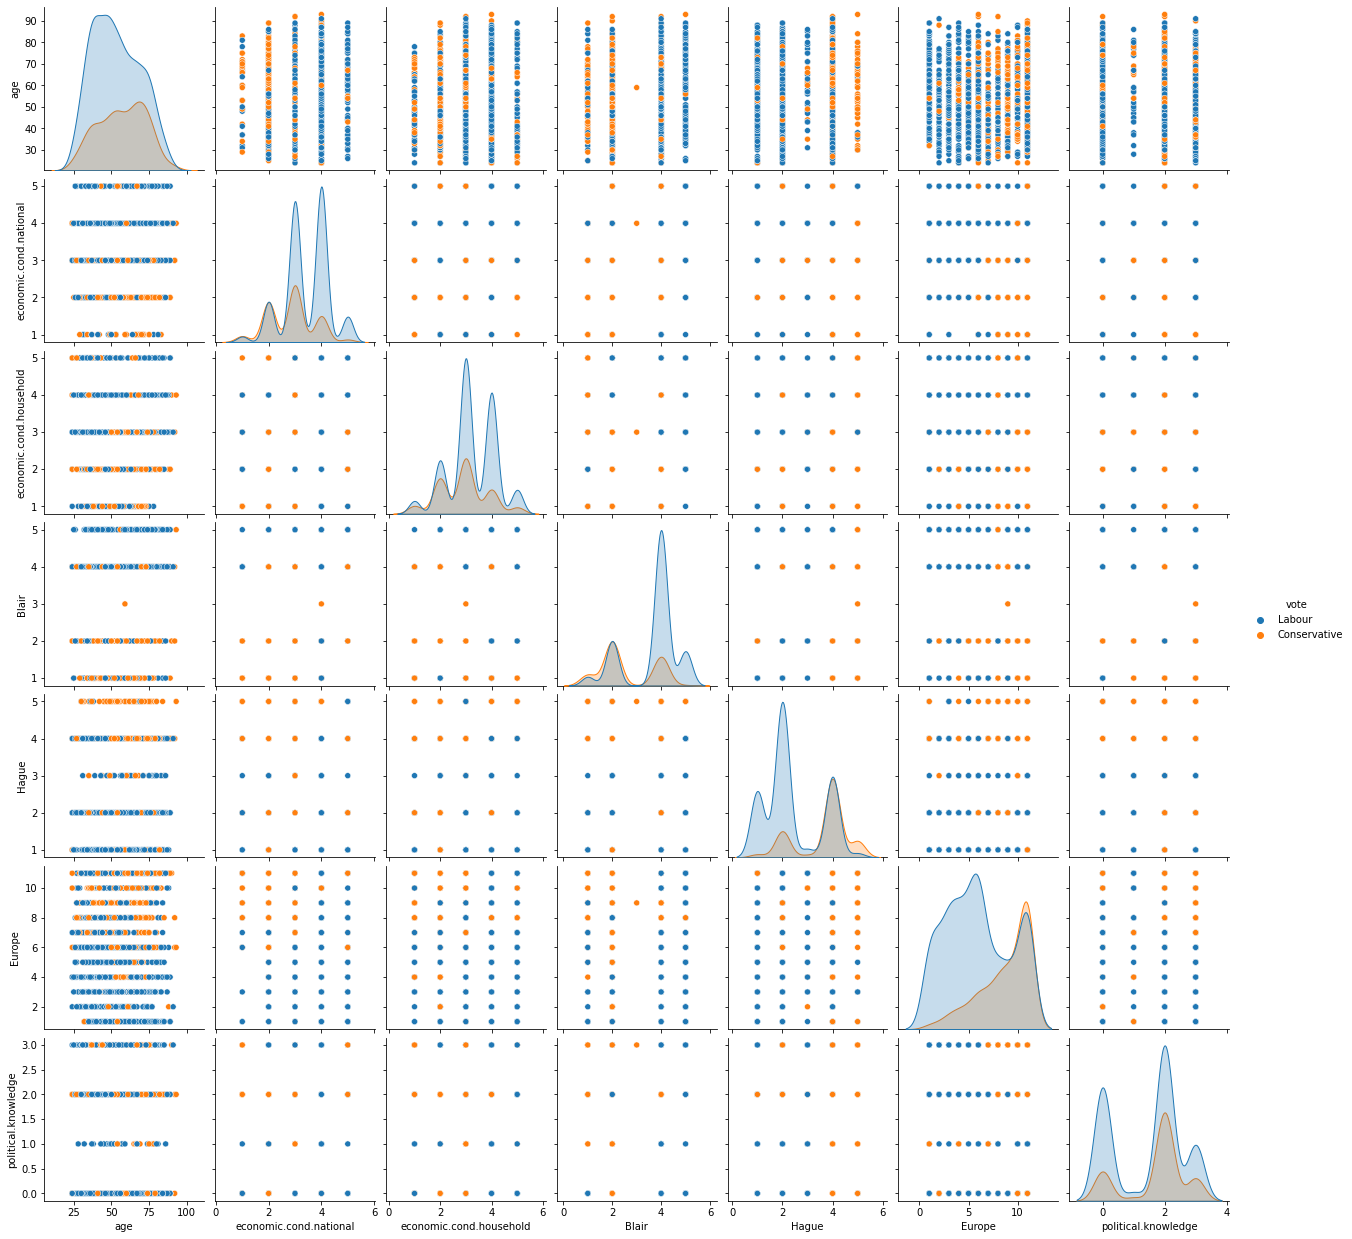

In [21]:
#multivariate analysis
sns.pairplot(df,hue="vote")

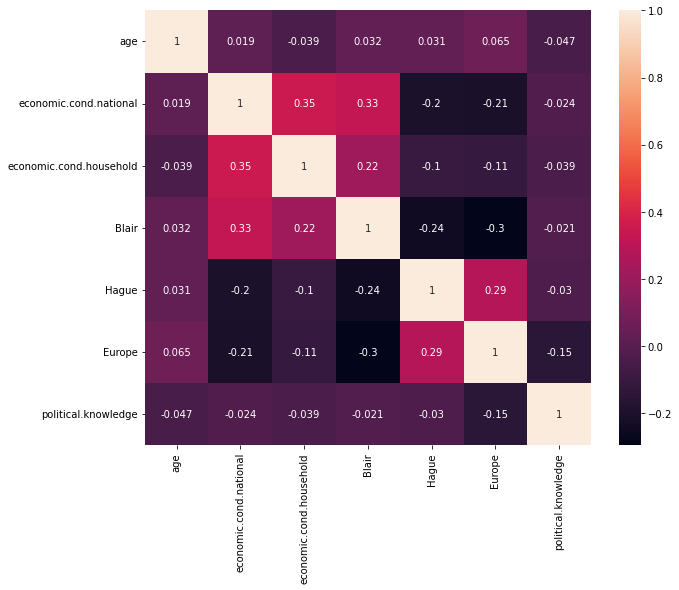

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

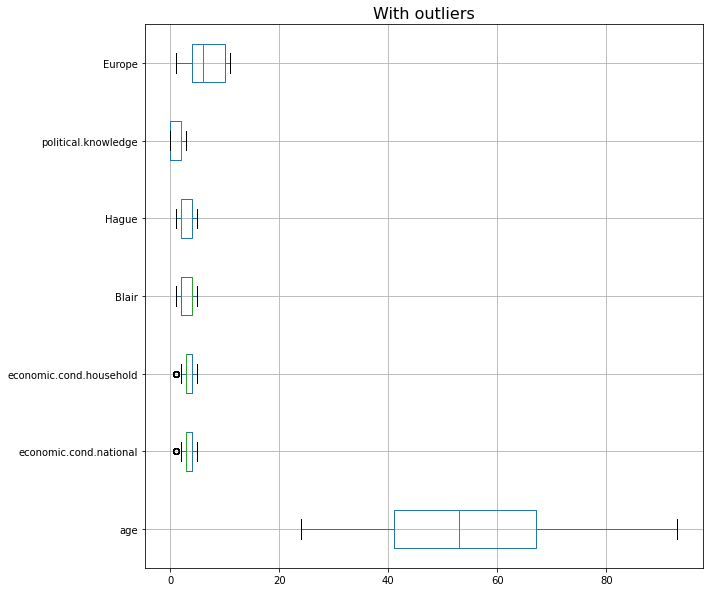

In [23]:
#outlier check
cols = ["age","economic.cond.national","economic.cond.household","Blair","Hague","political.knowledge","Europe"]
plt.figure(figsize=(10,10))
df[cols].boxplot(vert=0)
plt.title("With outliers",fontsize=16)
plt.show()

In [24]:
#encoding gender column
cat1=["gender"]
df=pd.get_dummies(df,columns=cat1,drop_first=True) 

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
#we are applying label encoding on vote
LE=LabelEncoder()

In [31]:
df["vote"]=LE.fit_transform(df["vote"])

In [32]:
df.shape

(1517, 9)

In [33]:
# 1=labour and 0 = conservative
df.head()

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender_male
0,1,43,3,3,4,1,2,2,0
1,1,36,4,4,4,4,5,2,1
2,1,35,4,4,5,2,3,2,1
3,1,24,4,2,2,1,4,0,0
4,1,41,2,2,1,1,6,2,1


In [34]:
# train test split x and y into training and test set in 70:30 ratio with random state=1
x=df.drop("vote",axis=1)
y=df["vote"]

In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

# Logistic Regression

In [36]:

from sklearn.linear_model import LogisticRegression

In [37]:
model=LogisticRegression()
model.fit(x_train,y_train)

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [38]:
ytrain_predict=model.predict(x_train)
ytest_predict=model.predict(x_test)

In [39]:
ytest_predict_prob=model.predict_proba(x_test)

In [40]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: vote, dtype: int32

In [41]:
y_train.value_counts()

1    754
0    307
Name: vote, dtype: int64

## Training set


In [42]:
#accuracy score
model.score(x_train,y_train)

0.8360037700282752

In [43]:
from sklearn.metrics import roc_auc_score, roc_curve,classification_report, confusion_matrix,plot_confusion_matrix

AUC:0.890


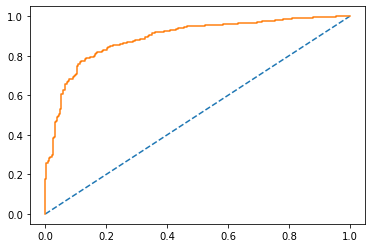

In [44]:
#auc_roc
probs=model.predict_proba(x_train)
probs=probs[:,1]
auc=roc_auc_score(y_train,probs)
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(y_train,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.75      0.65      0.70       307
           1       0.86      0.91      0.89       754

    accuracy                           0.84      1061
   macro avg       0.81      0.78      0.79      1061
weighted avg       0.83      0.84      0.83      1061



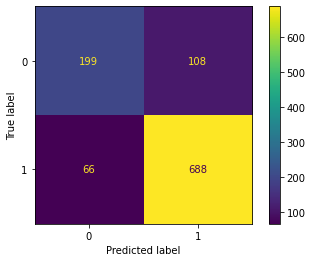

In [45]:
# confusion matrix and classification report
plot_confusion_matrix(model,x_train,y_train)
print(classification_report(y_train,ytrain_predict));


## testing set

In [46]:
model.score(x_test,y_test)

0.8267543859649122

AUC:0.877


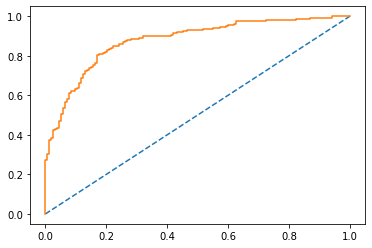

In [47]:
#auc_roc
probs=model.predict_proba(x_test)
probs=probs[:,1]
auc=roc_auc_score(y_test,probs)
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(y_test,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.75      0.72      0.74       153
           1       0.86      0.88      0.87       303

    accuracy                           0.83       456
   macro avg       0.81      0.80      0.80       456
weighted avg       0.83      0.83      0.83       456
 



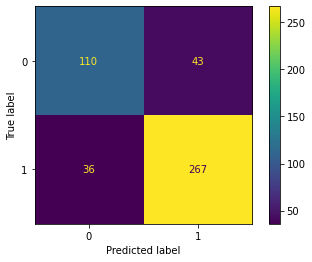

In [48]:
# confusion matrix and classification report
plot_confusion_matrix(model,x_test,y_test);
print(classification_report(y_test,ytest_predict),'\n');

In [50]:
from sklearn.model_selection import GridSearchCV

In [51]:
param_grid={
    "solver": ["newton-cg", "lbfgs"],
    "penalty" : ["l2","l1"]
}
logreg=LogisticRegression()

In [53]:
grid_search=GridSearchCV(estimator=logreg,param_grid=param_grid,cv=3)

In [54]:
grid_search.fit(x_train,y_train)

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

GridSearchCV(cv=3, estimator=LogisticRegression(),
             param_grid={'penalty': ['l2', 'l1'],
                         'solver': ['newton-cg', 'lbfgs']})

In [55]:
grid_search.best_params_

{'penalty': 'l2', 'solver': 'newton-cg'}

In [56]:
grid_search.best_estimator_

LogisticRegression(solver='newton-cg')

In [57]:
best_grid=grid_search.best_estimator_

In [58]:
ytrain_predict=best_grid.predict(x_train)
ytest_predict=best_grid.predict(x_test)

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.74      0.64      0.69       307
           1       0.86      0.91      0.88       754

    accuracy                           0.83      1061
   macro avg       0.80      0.77      0.79      1061
weighted avg       0.83      0.83      0.83      1061



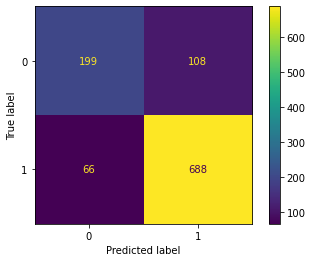

In [59]:
# confusion matrix and classification report after gridsearch cv
plot_confusion_matrix(model,x_train,y_train)
print(classification_report(y_train,ytrain_predict));


C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.76      0.74      0.75       153
           1       0.87      0.88      0.88       303

    accuracy                           0.84       456
   macro avg       0.82      0.81      0.81       456
weighted avg       0.83      0.84      0.83       456
 



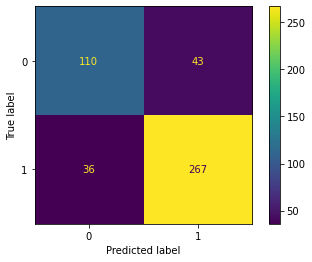

In [60]:
# confusion matrix and classification report testing set after grid search cv
plot_confusion_matrix(model,x_test,y_test);
print(classification_report(y_test,ytest_predict),'\n');

# NAIVE BAYES

In [62]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [63]:
naive=GaussianNB()
naive.fit(x_train,y_train)

GaussianNB()

In [66]:
ytrain_predict=naive.predict(x_train)
ytest_predict=naive.predict(x_test)

## Training set

In [67]:
#accuracy score
naive.score(x_train,y_train)

0.8350612629594723

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.73      0.69      0.71       307
           1       0.88      0.90      0.89       754

    accuracy                           0.84      1061
   macro avg       0.80      0.79      0.80      1061
weighted avg       0.83      0.84      0.83      1061



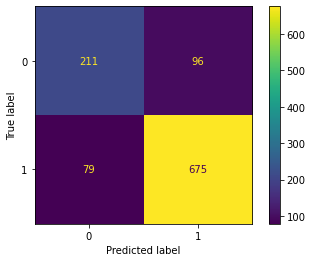

In [68]:
# confusion matrix and classification report
plot_confusion_matrix(naive,x_train,y_train)
print(classification_report(y_train,ytrain_predict));


AUC:0.888


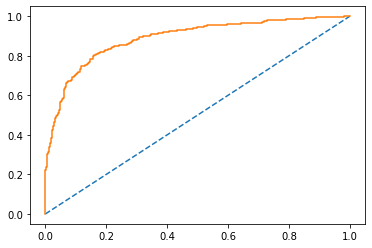

In [71]:
#auc_roc
probs=naive.predict_proba(x_train)
probs=probs[:,1]
auc=roc_auc_score(y_train,probs)
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(y_train,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

## Testing set

In [69]:
naive.score(x_test,y_test)

0.8223684210526315

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.74      0.73      0.73       153
           1       0.87      0.87      0.87       303

    accuracy                           0.82       456
   macro avg       0.80      0.80      0.80       456
weighted avg       0.82      0.82      0.82       456
 



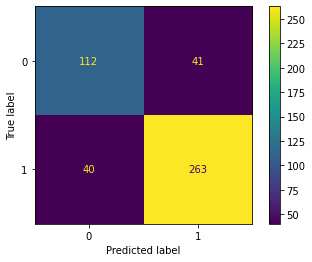

In [70]:
# confusion matrix and classification report
plot_confusion_matrix(naive,x_test,y_test);
print(classification_report(y_test,ytest_predict),'\n');

AUC:0.876


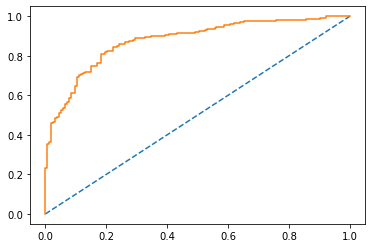

In [72]:
#auc_roc
probs=naive.predict_proba(x_test)
probs=probs[:,1]
auc=roc_auc_score(y_test,probs)
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(y_test,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

In [73]:
df.head()

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender_male
0,1,43,3,3,4,1,2,2,0
1,1,36,4,4,4,4,5,2,1
2,1,35,4,4,5,2,3,2,1
3,1,24,4,2,2,1,4,0,0
4,1,41,2,2,1,1,6,2,1


## We are doing scaling on "age" column as for KNN and LDA it is necessary

# LDA

In [75]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import zscore

In [78]:
X = df.drop("vote",axis=1)
Y=df["vote"]

In [80]:
X[["age"]]=X[["age"]].apply(zscore)

In [81]:
clf=LinearDiscriminantAnalysis()

In [82]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.30,random_state=1)

In [83]:
model=clf.fit(X_train,Y_train)

In [84]:
pred_class_train=model.predict(X_train)
pred_class_test=model.predict(X_test)

## Training set

In [85]:
#accuracy score
model.score(X_train,Y_train)

0.8341187558906692

In [86]:
pred_prob_train=model.predict_proba(X_train)
pred_prob_test=model.predict_proba(X_test)

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.74      0.65      0.69       307
           1       0.86      0.91      0.89       754

    accuracy                           0.83      1061
   macro avg       0.80      0.78      0.79      1061
weighted avg       0.83      0.83      0.83      1061
 



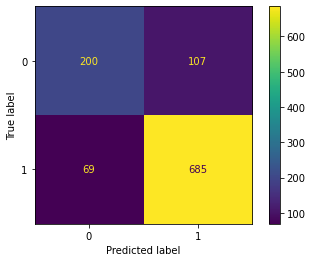

In [88]:
plot_confusion_matrix(model,X_train,Y_train);
print(classification_report(Y_train,pred_class_train),'\n');

AUC:0.889


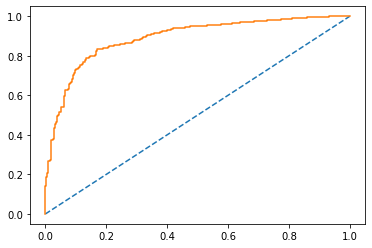

In [91]:
#auc_roc
probs=model.predict_proba(X_train)
probs=probs[:,1]
auc=roc_auc_score(Y_train,probs)
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(Y_train,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

## Testing set

In [89]:
#accuracy score
model.score(X_test,Y_test)

0.8333333333333334

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.77      0.73      0.74       153
           1       0.86      0.89      0.88       303

    accuracy                           0.83       456
   macro avg       0.82      0.81      0.81       456
weighted avg       0.83      0.83      0.83       456
 



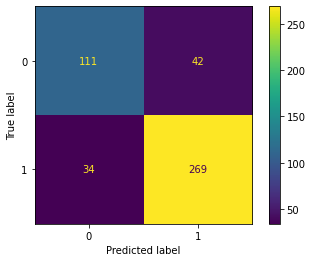

In [90]:
plot_confusion_matrix(model,X_test,Y_test);
print(classification_report(Y_test,pred_class_test),'\n');

AUC:0.888


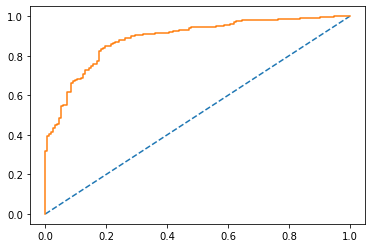

In [92]:
#auc_roc
probs=model.predict_proba(X_test)
probs=probs[:,1]
auc=roc_auc_score(Y_test,probs)
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(Y_test,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

In [96]:
# scaling only age and without scaling - we are getting almost same result for LDA

# KNN

In [98]:
from sklearn.neighbors import KNeighborsClassifier

In [99]:
X.head()

,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender_male
0,-0.716161,3,3,4,1,2,2,0
1,-1.162118,4,4,4,4,5,2,1
2,-1.225827,4,4,5,2,3,2,1
3,-1.926617,4,2,2,1,4,0,0
4,-0.843577,2,2,1,1,6,2,1


In [100]:
xscaled=X.apply(zscore)

In [101]:
xscaled.head()

,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender_male
0,-0.716161,-0.278185,-0.148020,0.565802,-1.419969,-1.437338,0.423832,-0.936736
1,-1.162118,0.856242,0.926367,0.565802,1.014951,-0.527684,0.423832,1.067536
2,-1.225827,0.856242,0.926367,1.417312,-0.608329,-1.134120,0.423832,1.067536
3,-1.926617,0.856242,-1.222408,-1.137217,-1.419969,-0.830902,-1.421084,-0.936736
4,-0.843577,-1.412613,-1.222408,-1.988727,-1.419969,-0.224465,0.423832,1.067536


In [102]:
x_train,x_test,Y_train,Y_test=train_test_split(xscaled,Y,test_size=0.30,random_state=1)

In [103]:
knn=KNeighborsClassifier()
knn.fit(x_train,Y_train)

KNeighborsClassifier()

In [104]:
ytrain_predict=knn.predict(x_train)
ytest_predict=knn.predict(x_test)

In [106]:
ytest_predict_prob=knn.predict_proba(x_test)

## Training set

In [108]:
#accuracy score
knn.score(x_train,Y_train)

0.8557964184731386

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.77      0.71      0.74       307
           1       0.89      0.92      0.90       754

    accuracy                           0.86      1061
   macro avg       0.83      0.81      0.82      1061
weighted avg       0.85      0.86      0.85      1061



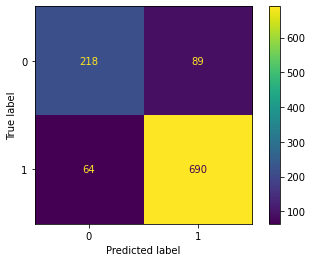

In [113]:
# confusion matrix and classification report
plot_confusion_matrix(knn,x_train,Y_train)
print(classification_report(Y_train,ytrain_predict));


## Testing set

In [114]:
#accuracy score test set
knn.score(x_test,Y_test)

0.8245614035087719

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.77      0.69      0.72       153
           1       0.85      0.89      0.87       303

    accuracy                           0.82       456
   macro avg       0.81      0.79      0.80       456
weighted avg       0.82      0.82      0.82       456
 



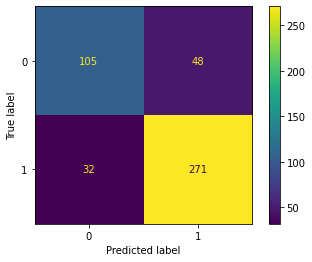

In [115]:
# confusion matrix and classification report
plot_confusion_matrix(knn,x_test,Y_test);
print(classification_report(Y_test,ytest_predict),'\n');

In [154]:
# model tuning using grid search

In [172]:
param_grid={
    "n_neighbors": [9,11,13,15,17,19],
    "weights" : ["uniform","distance"]
}
KNN=KNeighborsClassifier()

In [173]:
grid_search=GridSearchCV(estimator=KNN,param_grid=param_grid,cv=3)

In [174]:
grid_search.fit(x_train,Y_train)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [9, 11, 13, 15, 17, 19],
                         'weights': ['uniform', 'distance']})

In [175]:
grid_search.best_params_

{'n_neighbors': 17, 'weights': 'distance'}

In [176]:
best_grid=grid_search.best_estimator_

In [177]:
ytrain_predict=best_grid.predict(x_train)
ytest_predict=best_grid.predict(x_test)

In [178]:
# confusion matrix and classification report after gridsearch cv training set
confusion_matrix(Y_train,ytrain_predict)


array([[307,   0],
       [  0, 754]], dtype=int64)

In [179]:
print(classification_report(Y_train,ytrain_predict));

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       307
           1       1.00      1.00      1.00       754

    accuracy                           1.00      1061
   macro avg       1.00      1.00      1.00      1061
weighted avg       1.00      1.00      1.00      1061



AUC:0.900


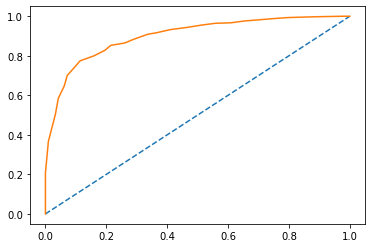

In [186]:
#auc_roc
probs=knn.predict_proba(x_train)
probs=probs[:,1]
auc=roc_auc_score(Y_train,probs)
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(Y_train,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

In [180]:
# confusion matrix and classification report after gridsearch cv testing set
confusion_matrix(Y_test,ytest_predict)

array([[100,  53],
       [ 26, 277]], dtype=int64)

In [181]:
print(classification_report(Y_test,ytest_predict))

              precision    recall  f1-score   support

           0       0.79      0.65      0.72       153
           1       0.84      0.91      0.88       303

    accuracy                           0.83       456
   macro avg       0.82      0.78      0.80       456
weighted avg       0.82      0.83      0.82       456



AUC:0.887


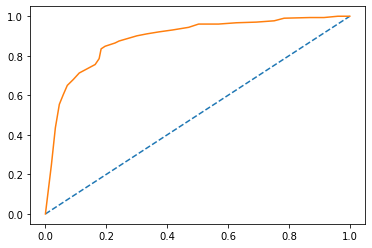

In [187]:
#auc_roc
probs=knn.predict_proba(x_test)
probs=probs[:,1]
auc=roc_auc_score(Y_test,probs)
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(Y_test,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

In [182]:
ac_scores=[]
for k in range (1,30):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,Y_train)
    scores=knn.score(x_test,Y_test)
    ac_scores.append(scores)
MCE=[1-x for x in ac_scores]
MCE

[0.2171052631578947,
 0.22587719298245612,
 0.1907894736842105,
 0.1885964912280702,
 0.17543859649122806,
 0.1885964912280702,
 0.18201754385964908,
 0.1842105263157895,
 0.17763157894736847,
 0.16885964912280704,
 0.17105263157894735,
 0.16447368421052633,
 0.17763157894736847,
 0.16885964912280704,
 0.17324561403508776,
 0.16228070175438591,
 0.16666666666666663,
 0.1557017543859649,
 0.16666666666666663,
 0.16228070175438591,
 0.17105263157894735,
 0.16447368421052633,
 0.17105263157894735,
 0.1557017543859649,
 0.16885964912280704,
 0.1578947368421053,
 0.16228070175438591,
 0.1600877192982456,
 0.17105263157894735]

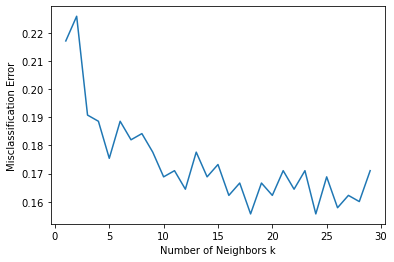

In [183]:
plt.plot(range(1,30),MCE)
plt.xlabel("Number of Neighbors k")
plt.ylabel("Misclassification Error")
plt.show()

## Adaboosting

In [188]:
# boosting
from sklearn.ensemble import AdaBoostClassifier

abcl=AdaBoostClassifier(n_estimators=10,random_state=1)
abcl=abcl.fit(x_train,y_train)

In [189]:
#training set
y_train_predict=abcl.predict(x_train)
model_score=abcl.score(x_train,y_train)
print(model_score)
print(metrics.confusion_matrix(y_train,y_train_predict))
print(metrics.classification_report(y_train,y_train_predict))

0.8426013195098964
[[206 101]
 [ 66 688]]
              precision    recall  f1-score   support

           0       0.76      0.67      0.71       307
           1       0.87      0.91      0.89       754

    accuracy                           0.84      1061
   macro avg       0.81      0.79      0.80      1061
weighted avg       0.84      0.84      0.84      1061



AUC:0.898


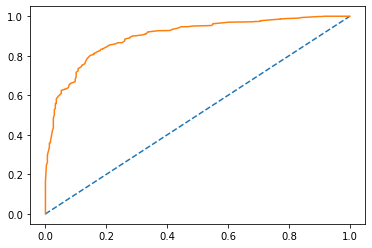

In [191]:
#auc_roc
probs=abcl.predict_proba(x_train)
probs=probs[:,1]
auc=roc_auc_score(y_train,probs)
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(y_train,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

In [190]:
#test set
y_test_predict=abcl.predict(x_test)
model_score=abcl.score(x_test,y_test)
print(model_score)
print(metrics.confusion_matrix(y_test,y_test_predict))
print(metrics.classification_report(y_test,y_test_predict))

0.8201754385964912
[[110  43]
 [ 39 264]]
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       153
           1       0.86      0.87      0.87       303

    accuracy                           0.82       456
   macro avg       0.80      0.80      0.80       456
weighted avg       0.82      0.82      0.82       456



AUC:0.878


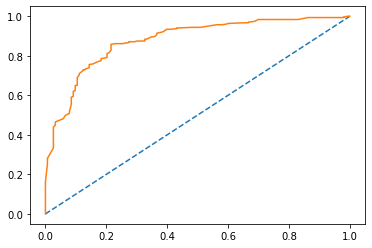

In [192]:
#auc_roc
probs=abcl.predict_proba(x_test)
probs=probs[:,1]
auc=roc_auc_score(y_test,probs)
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(y_test,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

## gradient boosting

In [193]:
from sklearn.ensemble import GradientBoostingClassifier
gbcl=GradientBoostingClassifier(random_state=1)
gbcl=gbcl.fit(x_train,y_train)

In [194]:
#training set
y_train_predict=gbcl.predict(x_train)
model_score=gbcl.score(x_train,y_train)
print(model_score)
print(metrics.confusion_matrix(y_train,y_train_predict))
print(metrics.classification_report(y_train,y_train_predict))

0.8925541941564562
[[239  68]
 [ 46 708]]
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       307
           1       0.91      0.94      0.93       754

    accuracy                           0.89      1061
   macro avg       0.88      0.86      0.87      1061
weighted avg       0.89      0.89      0.89      1061



AUC:0.951


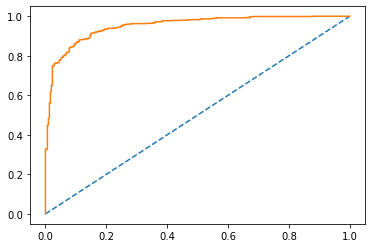

In [195]:
#auc_roc
probs=gbcl.predict_proba(x_train)
probs=probs[:,1]
auc=roc_auc_score(y_train,probs)
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(y_train,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

In [196]:
#test set
y_test_predict=gbcl.predict(x_test)
model_score=gbcl.score(x_test,y_test)
print(model_score)
print(metrics.confusion_matrix(y_test,y_test_predict))
print(metrics.classification_report(y_test,y_test_predict))

0.8355263157894737
[[105  48]
 [ 27 276]]
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       153
           1       0.85      0.91      0.88       303

    accuracy                           0.84       456
   macro avg       0.82      0.80      0.81       456
weighted avg       0.83      0.84      0.83       456



AUC:0.899


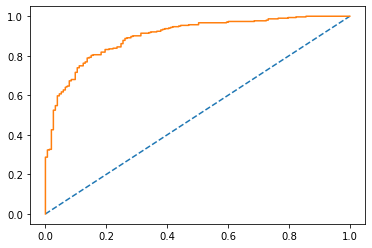

In [197]:
#auc_roc
probs=gbcl.predict_proba(x_test)
probs=probs[:,1]
auc=roc_auc_score(y_test,probs)
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(y_test,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

# Bagging

In [198]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
rfcl=RandomForestClassifier()
bagging=BaggingClassifier(base_estimator=rfcl,n_estimators=50,random_state=1)
bagging.fit(x_train,y_train)

BaggingClassifier(base_estimator=RandomForestClassifier(), n_estimators=50,
                  random_state=1)

In [199]:
#training set
y_train_predict=bagging.predict(x_train)
model_score=bagging.score(x_train,y_train)
print(model_score)
print(metrics.confusion_matrix(y_train,y_train_predict))
print(metrics.classification_report(y_train,y_train_predict))

0.9651272384542884
[[277  30]
 [  7 747]]
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       307
           1       0.96      0.99      0.98       754

    accuracy                           0.97      1061
   macro avg       0.97      0.95      0.96      1061
weighted avg       0.97      0.97      0.96      1061



AUC:0.997


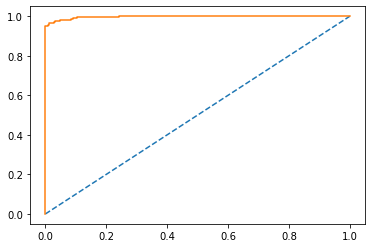

In [200]:
#auc_roc
probs=bagging.predict_proba(x_train)
probs=probs[:,1]
auc=roc_auc_score(y_train,probs)
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(y_train,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

In [201]:
#test set
y_test_predict=bagging.predict(x_test)
model_score=bagging.score(x_test,y_test)
print(model_score)
print(metrics.confusion_matrix(y_test,y_test_predict))
print(metrics.classification_report(y_test,y_test_predict))

0.8289473684210527
[[103  50]
 [ 28 275]]
              precision    recall  f1-score   support

           0       0.79      0.67      0.73       153
           1       0.85      0.91      0.88       303

    accuracy                           0.83       456
   macro avg       0.82      0.79      0.80       456
weighted avg       0.83      0.83      0.83       456



AUC:0.895


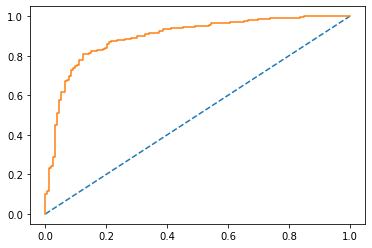

In [202]:
#auc_roc
probs=bagging.predict_proba(x_test)
probs=probs[:,1]
auc=roc_auc_score(y_test,probs)
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(y_test,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

In [20]:
import nltk
nltk.download('inaugural')
from nltk.corpus import inaugural
inaugural.fileids()
inaugural.raw('1941-Roosevelt.txt')
inaugural.raw('1961-Kennedy.txt')
inaugural.raw('1973-Nixon.txt')

[nltk_data] Downloading package inaugural to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package inaugural is already up-to-date!


'Mr. Vice President, Mr. Speaker, Mr. Chief Justice, Senator Cook, Mrs. Eisenhower, and my fellow citizens of this great and good country we share together:\n\nWhen we met here four years ago, America was bleak in spirit, depressed by the prospect of seemingly endless war abroad and of destructive conflict at home.\n\nAs we meet here today, we stand on the threshold of a new era of peace in the world.\n\nThe central question before us is: How shall we use that peace? Let us resolve that this era we are about to enter will not be what other postwar periods have so often been: a time of retreat and isolation that leads to stagnation at home and invites new danger abroad.\n\nLet us resolve that this will be what it can become: a time of great responsibilities greatly borne, in which we renew the spirit and the promise of America as we enter our third century as a nation.\n\nThis past year saw far-reaching results from our new policies for peace. By continuing to revitalize our traditional

In [39]:
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [40]:
print("The number of sentences =", len(inaugural.sents()))
print("The number of words =", len([word for sentence in inaugural.sents() for word in sentence]))
print("The number of characters =", len([char for sentence in inaugural.sents() for word in sentence for char in word]))

The number of sentences = 5217
The number of words = 152901
The number of characters = 667512


In [41]:
all_words=[]
def lower(x):
    for w in x.words():
        words=w.lower()
        all_words.append(words)
lower(inaugural)
all_words

['fellow',
 '-',
 'citizens',
 'of',
 'the',
 'senate',
 'and',
 'of',
 'the',
 'house',
 'of',
 'representatives',
 ':',
 'among',
 'the',
 'vicissitudes',
 'incident',
 'to',
 'life',
 'no',
 'event',
 'could',
 'have',
 'filled',
 'me',
 'with',
 'greater',
 'anxieties',
 'than',
 'that',
 'of',
 'which',
 'the',
 'notification',
 'was',
 'transmitted',
 'by',
 'your',
 'order',
 ',',
 'and',
 'received',
 'on',
 'the',
 '14th',
 'day',
 'of',
 'the',
 'present',
 'month',
 '.',
 'on',
 'the',
 'one',
 'hand',
 ',',
 'i',
 'was',
 'summoned',
 'by',
 'my',
 'country',
 ',',
 'whose',
 'voice',
 'i',
 'can',
 'never',
 'hear',
 'but',
 'with',
 'veneration',
 'and',
 'love',
 ',',
 'from',
 'a',
 'retreat',
 'which',
 'i',
 'had',
 'chosen',
 'with',
 'the',
 'fondest',
 'predilection',
 ',',
 'and',
 ',',
 'in',
 'my',
 'flattering',
 'hopes',
 ',',
 'with',
 'an',
 'immutable',
 'decision',
 ',',
 'as',
 'the',
 'asylum',
 'of',
 'my',
 'declining',
 'years',
 '--',
 'a',
 'retreat

In [42]:
import string
stopwords=nltk.corpus.stopwords.words("english")+list(string.punctuation)
print(stopwords)

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [43]:
all_words_clean=[]
def clean(x):
    for word in x:
        if word not in stopwords:
            all_words_clean.append(word)
clean(all_words)
all_words_clean

['fellow',
 'citizens',
 'senate',
 'house',
 'representatives',
 'among',
 'vicissitudes',
 'incident',
 'life',
 'event',
 'could',
 'filled',
 'greater',
 'anxieties',
 'notification',
 'transmitted',
 'order',
 'received',
 '14th',
 'day',
 'present',
 'month',
 'one',
 'hand',
 'summoned',
 'country',
 'whose',
 'voice',
 'never',
 'hear',
 'veneration',
 'love',
 'retreat',
 'chosen',
 'fondest',
 'predilection',
 'flattering',
 'hopes',
 'immutable',
 'decision',
 'asylum',
 'declining',
 'years',
 '--',
 'retreat',
 'rendered',
 'every',
 'day',
 'necessary',
 'well',
 'dear',
 'addition',
 'habit',
 'inclination',
 'frequent',
 'interruptions',
 'health',
 'gradual',
 'waste',
 'committed',
 'time',
 'hand',
 'magnitude',
 'difficulty',
 'trust',
 'voice',
 'country',
 'called',
 'sufficient',
 'awaken',
 'wisest',
 'experienced',
 'citizens',
 'distrustful',
 'scrutiny',
 'qualifications',
 'could',
 'overwhelm',
 'despondence',
 'one',
 'inheriting',
 'inferior',
 'endowment

In [44]:
nltk.FreqDist(all_words_clean)

FreqDist({'government': 600, 'people': 594, 'us': 502, 'must': 374, 'upon': 371, '--': 363, 'great': 346, 'world': 346, 'may': 343, 'states': 335, ...})

In [45]:
all_words_freq=nltk.FreqDist(all_words_clean)
all_words_freq

FreqDist({'government': 600, 'people': 594, 'us': 502, 'must': 374, 'upon': 371, '--': 363, 'great': 346, 'world': 346, 'may': 343, 'states': 335, ...})

In [32]:
inaugural.words(inaugural.fileids())

['Fellow', '-', 'Citizens', 'of', 'the', 'Senate', ...]

In [48]:
nltk.FreqDist(inaugural.words('1941-Roosevelt.txt')).most_common(3)

[('the', 104), ('of', 81), (',', 77)]

In [37]:
nltk.FreqDist(inaugural.words('1961-Kennedy.txt')).most_common(3)

[(',', 85), ('the', 83), ('of', 65)]

In [38]:
nltk.FreqDist(inaugural.words('1973-Nixon.txt')).most_common(3)

[(',', 96), ('the', 80), ('.', 68)]

In [49]:
roosevelt=inaugural.raw(fileids="1941-Roosevelt.txt")

In [50]:
len(roosevelt)

7571

In [52]:
print(roosevelt[0:98])

On each national day of inauguration since 1789, the people have renewed their sense of dedication
